In [83]:
import pandas as pd
import numpy as np

# Data Preparation

In [84]:
url = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv'

data = pd.read_csv(url)
len(data)

7043

In [85]:
df = data.copy()

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [86]:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [87]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [88]:
df.dtypes[df.dtypes == 'object'].index

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')

In [89]:
categorical_cols = list(df.dtypes[df.dtypes == 'object'].index)
categorical_cols

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'TotalCharges',
 'Churn']

In [90]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']
 
# Removing 'customerid', 'tenure', 'monthlycharges', 'totalcharges', and 'churn'
categorical = ['gender', 'seniorcitizen', 'partner', 'dependents',
       'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod']

In [91]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [92]:
for col in categorical_cols:
    df[col] = df[col].str.lower().str.replace(' ', '_')

KeyError: 'customerID'

In [94]:
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [95]:
nemerical_Cols = list(df.dtypes[df.dtypes != "object"].index)

In [96]:
nemerical_Cols

['seniorcitizen', 'tenure', 'monthlycharges']

In [97]:
# pd.to_numeric(df.totalcharges)

In [98]:
tc = pd.to_numeric(df.totalcharges, errors = "coerce")

In [99]:
df.totalcharges = pd.to_numeric(df.totalcharges, errors = "coerce")

In [100]:
df.totalcharges

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: totalcharges, Length: 7043, dtype: float64

In [101]:
tc.isnull().sum()

11

In [102]:
df.dtypes

customerid           object
gender               object
seniorcitizen         int64
partner              object
dependents           object
tenure                int64
phoneservice         object
multiplelines        object
internetservice      object
onlinesecurity       object
onlinebackup         object
deviceprotection     object
techsupport          object
streamingtv          object
streamingmovies      object
contract             object
paperlessbilling     object
paymentmethod        object
monthlycharges      float64
totalcharges        float64
churn                object
dtype: object

In [103]:
df[tc.isnull()][["customerid", "totalcharges"]]

,customerid,totalcharges
488,4472-LVYGI,NaN
753,3115-CZMZD,NaN
936,5709-LVOEQ,NaN
1082,4367-NUYAO,NaN
1340,1371-DWPAZ,NaN
3331,7644-OMVMY,NaN
3826,3213-VVOLG,NaN
4380,2520-SGTTA,NaN
5218,2923-ARZLG,NaN
6670,4075-WKNIU,NaN


In [104]:
df.totalcharges.isnull().sum()

11

In [105]:
df.churn.unique()

array(['No', 'Yes'], dtype=object)

In [106]:
df.totalcharges = df.totalcharges.fillna(0)

In [107]:
df.totalcharges.isnull().sum()

0

In [108]:
df.churn.unique()

array(['No', 'Yes'], dtype=object)

we churn = 'yes' as '1'& churn = 'no' as 0

In [109]:
(df.churn == 'Yes').astype(int).head(), df.churn.head()

(0    0
 1    0
 2    1
 3    0
 4    1
 Name: churn, dtype: int32,
 0     No
 1     No
 2    Yes
 3     No
 4    Yes
 Name: churn, dtype: object)

In [110]:
df.churn = (df.churn == 'Yes').astype(int)

In [111]:
df.churn

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: churn, Length: 7043, dtype: int32

In [112]:
from sklearn.model_selection import train_test_split

In [113]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)

In [114]:
len(df_full_train), len(df_test)

(5634, 1409)

In [115]:
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)
len(df_train), len(df_val)

(4225, 1409)

In [116]:
len(df_train), len(df_val), len(df_test)

(4225, 1409, 1409)

In [117]:
len(df_train) + len(df_val) +len(df_test)

7043

In [118]:
df_full_train = df_full_train.reset_index(drop = True)
df_train = df_train.reset_index(drop = True)
df_val = df_val.reset_index(drop = True)
df_test = df_test.reset_index(drop = True)

In [119]:
y_full_train = df_full_train.churn.values
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

In [184]:
y_train

array([0, 0, 1, ..., 1, 0, 1])

In [120]:
# del df_full_train['churn']
# del df_train['churn']
# del df_val['churn']
# del df_test['churn'] 

In [121]:
df_full_train.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [122]:
global_churn = df_full_train.churn.mean()
global_churn

0.26996805111821087

In [123]:
df.churn.unique()

array([0, 1])

In [124]:
df_full_train[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

In [125]:
df_full_train[numerical].nunique()

tenure              73
monthlycharges    1494
totalcharges      5291
dtype: int64

### exploring the feature importance: Churn rate and risk ratio

In [126]:
gender_rate = df_full_train.groupby('gender').churn.agg(['mean'])
gender_rate

,mean
gender,
Female,0.276824
Male,0.263214


In [127]:
female_rate = gender_rate['mean'].iloc[0]
male_rate = gender_rate['mean'].iloc[1]

In [128]:
female_rate - global_churn

0.006855983216553063

In [129]:
male_rate - global_churn

-0.006754520462819769

Here both categories of gender aren't likely important 

In [130]:
df_group = df_full_train.groupby('gender').churn.agg(['mean', 'count'])
df_group['diff'] = df_group['mean'] - global_churn
df_group['risk'] = df_group['mean'] / global_churn
df_group

,mean,count,diff,risk
gender,,,,
Female,0.276824,2796,0.006856,1.025396
Male,0.263214,2838,-0.006755,0.974980


In [131]:
from IPython.display import display

for col in categorical:
    df_group = df_full_train.groupby(col).churn.agg(['mean', 'count'])
    df_group['diff'] = df_group['mean'] - global_churn
    df_group['risk'] = df_group['mean'] / global_churn
    print(col)
    display(df_group)


    print("\n")

gender


,mean,count,diff,risk
gender,,,,
Female,0.276824,2796,0.006856,1.025396
Male,0.263214,2838,-0.006755,0.974980




seniorcitizen


,mean,count,diff,risk
seniorcitizen,,,,
0,0.242270,4722,-0.027698,0.897403
1,0.413377,912,0.143409,1.531208




partner


...

,mean,count,diff,risk
contract,,,,
Month-to-month,0.431701,3104,0.161733,1.599082
One year,0.120573,1186,-0.149395,0.446621
Two year,0.028274,1344,-0.241694,0.104730




paperlessbilling


,mean,count,diff,risk
paperlessbilling,,,,
No,0.172071,2313,-0.097897,0.637375
Yes,0.338151,3321,0.068183,1.252560




paymentmethod


,mean,count,diff,risk
paymentmethod,,,,
Bank transfer (automatic),0.168171,1219,-0.101797,0.622928
Credit card (automatic),0.164339,1217,-0.105630,0.608733
Electronic check,0.455890,1893,0.185922,1.688682
Mailed check,0.193870,1305,-0.076098,0.718121


## relatively high value RR
- seniorcitizen : 1 (senior)
- internetservice : fiber_optic
- onlinesecurity : no
- techsupport : no
- contract : month-to-month
- paymentmethod : electronic_check

Values for this difference smaller than 0 indicate a higher likelihood to churn,
while values larger than 0 indicate a lower likelihood to churn.

As for the risk ratio, it is obtained by dividing the group’s churn rate by the global churn rate. 
Values greater than 1 suggest a higher likelihood to churn, whereas values less than 1 suggest a lower likelihood to churn.

# Feature importance
> Measuring the categorical features importance using "Mutual Infomration" method

In [132]:
from sklearn.metrics import mutual_info_score


for col in categorical:
    result = mutual_info_score(df_full_train.churn, df_full_train[col])

    print(col, result)

gender 0.0001174846211139946
seniorcitizen 0.009410216144208144
partner 0.009967689095399745
dependents 0.012345815445534689
phoneservice 0.00022871269738296285
multiplelines 0.0008574478744731856
internetservice 0.055867945893496467
onlinesecurity 0.06308524972985574
onlinebackup 0.0469234640537918
deviceprotection 0.04345286925268559
techsupport 0.06103245991777444
streamingtv 0.03185333110086085
streamingmovies 0.03158089669519908
contract 0.0983203874041556
paperlessbilling 0.01758882715925275
paymentmethod 0.043210027531582915


In [133]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_full_train.churn)
 
mi = df_full_train[categorical].apply(mutual_info_churn_score)
mi

gender              0.000117
seniorcitizen       0.009410
partner             0.009968
dependents          0.012346
phoneservice        0.000229
multiplelines       0.000857
internetservice     0.055868
onlinesecurity      0.063085
onlinebackup        0.046923
deviceprotection    0.043453
techsupport         0.061032
streamingtv         0.031853
streamingmovies     0.031581
contract            0.098320
paperlessbilling    0.017589
paymentmethod       0.043210
dtype: float64

In [134]:
mi.sort_values(ascending=False)

contract            0.098320
onlinesecurity      0.063085
techsupport         0.061032
internetservice     0.055868
onlinebackup        0.046923
deviceprotection    0.043453
paymentmethod       0.043210
streamingtv         0.031853
streamingmovies     0.031581
paperlessbilling    0.017589
dependents          0.012346
partner             0.009968
seniorcitizen       0.009410
multiplelines       0.000857
phoneservice        0.000229
gender              0.000117
dtype: float64

### Measuring the numerical features importance by getting the Correlation

- A negative correlation (r = -1) indicates a strong inverse relationship, where one variable increases as the other decreases.
- A positive correlation (r = 1) indicates a strong positive relationship, where both variables increase together.
- An r value close to 0 suggests a weak or no linear relationship between the variables.

 ### The strength of the correlation is indicated by the absolute value of r:

- 0.0 < |r| < 0.2: Low correlation
- 0.2 < |r| < 0.5: Moderate correlation
- 0.6 < |r| < 1.0: Strong correlation

In [135]:
df_full_train[numerical].corrwith(df_full_train.churn)


tenure           -0.351885
monthlycharges    0.196805
totalcharges     -0.196353
dtype: float64

In [136]:
df_full_train[numerical].corrwith(df_full_train.churn).abs().sort_values(ascending=False)

tenure            0.351885
monthlycharges    0.196805
totalcharges      0.196353
dtype: float64

In [137]:
temp_dict = df_train[['gender', 'contract']].iloc[:20].to_dict(orient='records')

In [138]:
temp_dict

[{'gender': 'Female', 'contract': 'Two year'},
 {'gender': 'Male', 'contract': 'Month-to-month'},
 {'gender': 'Female', 'contract': 'Month-to-month'},
 {'gender': 'Female', 'contract': 'Month-to-month'},
 {'gender': 'Female', 'contract': 'Two year'},
 {'gender': 'Male', 'contract': 'Month-to-month'},
 {'gender': 'Male', 'contract': 'Month-to-month'},
 {'gender': 'Female', 'contract': 'Month-to-month'},
 {'gender': 'Female', 'contract': 'Two year'},
 {'gender': 'Female', 'contract': 'Month-to-month'},
 {'gender': 'Female', 'contract': 'Two year'},
 {'gender': 'Male', 'contract': 'Month-to-month'},
 {'gender': 'Female', 'contract': 'Two year'},
 {'gender': 'Female', 'contract': 'Month-to-month'},
 {'gender': 'Female', 'contract': 'Month-to-month'},
 {'gender': 'Male', 'contract': 'Month-to-month'},
 {'gender': 'Female', 'contract': 'Two year'},
 {'gender': 'Female', 'contract': 'Month-to-month'},
 {'gender': 'Male', 'contract': 'One year'},
 {'gender': 'Male', 'contract': 'Two year'}]

In [139]:
df_train.contract.unique()

array(['Two year', 'Month-to-month', 'One year'], dtype=object)

In [140]:
unique_contracts = set(d["contract"] for d in temp_dict)
unique_contracts

{'Month-to-month', 'One year', 'Two year'}

In [141]:
# A sparse matrix is a memory-efficient way of encoding data when there are many zeros in the dataset. 
from sklearn.feature_extraction import DictVectorizer
dv = DictVectorizer(sparse=False)
dv.fit(temp_dict)
 
dv.get_feature_names_out()

array(['contract=Month-to-month', 'contract=One year',
       'contract=Two year', 'gender=Female', 'gender=Male'], dtype=object)

In [142]:
dv.transform(temp_dict)

array([[0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 0., 1.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 0., 1.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 0., 1.],
       [0., 0., 1., 1., 0.],
       [1., 0., 0., 1., 0.],
       [0., 1., 0., 0., 1.],
       [0., 0., 1., 0., 1.]])

In [143]:
temp_dict[0]

{'gender': 'Female', 'contract': 'Two year'}

In [144]:
del df_full_train['churn']
del df_train['churn']
del df_val['churn']
del df_test['churn'] 

In [145]:
train_dict = df_train[categorical + numerical].to_dict(orient='records')
train_dict[0]

{'gender': 'Female',
 'seniorcitizen': 0,
 'partner': 'Yes',
 'dependents': 'Yes',
 'phoneservice': 'Yes',
 'multiplelines': 'Yes',
 'internetservice': 'Fiber optic',
 'onlinesecurity': 'Yes',
 'onlinebackup': 'Yes',
 'deviceprotection': 'Yes',
 'techsupport': 'Yes',
 'streamingtv': 'Yes',
 'streamingmovies': 'Yes',
 'contract': 'Two year',
 'paperlessbilling': 'Yes',
 'paymentmethod': 'Electronic check',
 'tenure': 72,
 'monthlycharges': 115.5,
 'totalcharges': 8425.15}

In [146]:
dv_v = DictVectorizer(sparse=False)

# The DictVectorizer learns what features (keys and possible categorical values) exist in the data.
dv_v.fit(train_dict)

dv_v.get_feature_names_out()

array(['contract=Month-to-month', 'contract=One year',
       'contract=Two year', 'dependents=No', 'dependents=Yes',
       'deviceprotection=No', 'deviceprotection=No internet service',
       'deviceprotection=Yes', 'gender=Female', 'gender=Male',
       'internetservice=DSL', 'internetservice=Fiber optic',
       'internetservice=No', 'monthlycharges', 'multiplelines=No',
       'multiplelines=No phone service', 'multiplelines=Yes',
       'onlinebackup=No', 'onlinebackup=No internet service',
       'onlinebackup=Yes', 'onlinesecurity=No',
       'onlinesecurity=No internet service', 'onlinesecurity=Yes',
       'paperlessbilling=No', 'paperlessbilling=Yes', 'partner=No',
       'partner=Yes', 'paymentmethod=Bank transfer (automatic)',
       'paymentmethod=Credit card (automatic)',
       'paymentmethod=Electronic check', 'paymentmethod=Mailed check',
       'phoneservice=No', 'phoneservice=Yes', 'seniorcitizen',
       'streamingmovies=No', 'streamingmovies=No internet service',

In [147]:
X_train = dv_v.transform(train_dict)

In [148]:
X_train

array([[0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        7.20000e+01, 8.42515e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+01, 1.02155e+03],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        5.00000e+00, 4.13650e+02],
       ...,
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        2.00000e+00, 1.90050e+02],
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        2.70000e+01, 7.61950e+02],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        9.00000e+00, 7.51650e+02]])

In [149]:
X_train[0]

array([0.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00, 1.00000e+00,
       0.00000e+00, 0.00000e+00, 1.00000e+00, 1.00000e+00, 0.00000e+00,
       0.00000e+00, 1.00000e+00, 0.00000e+00, 1.15500e+02, 0.00000e+00,
       0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00,
       0.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00, 1.00000e+00,
       0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00,
       0.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00,
       0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00,
       0.00000e+00, 0.00000e+00, 1.00000e+00, 7.20000e+01, 8.42515e+03])

In [150]:
X_train.shape

(4225, 45)

In [153]:
unique_values_of_all_features = 0
for col in categorical:
    unique_values_of_all_features += df[col].nunique()    
unique_values_of_all_features

43

>When dealing with validation data, we can reuse the same DictVectorizer instance that we created before. Instead of using the fit function followed by the transform function, we only need to apply the transform function to the validation data. This ensures that the transformation process applied to the validation data is consistent with the encoding used for the training data.
>
> the vectorizer uses the same mapping it learned from training to convert validation data into numeric form.

> If validation_data contains unseen categories, those are simply ignored (or represented as zeros), but the order and meaning of columns remain identical to the training data.

In [199]:
val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv_v.transform(val_dicts)
X_val

array([[0.0000e+00, 0.0000e+00, 1.0000e+00, ..., 1.0000e+00, 7.1000e+01,
        4.9734e+03],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        2.0750e+01],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        2.0350e+01],
       ...,
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 1.0000e+00, 1.8000e+01,
        1.0581e+03],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 1.0000e+00,
        9.3300e+01],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 3.0000e+00,
        2.9285e+02]])

# Logistic Regression

> In binary classification, the target variable yiyi​ belongs to one of two classes: 0 or 1. These classes are often referred to as “negative” and “positive,” and they represent two mutually exclusive outcomes. In the context of churn prediction, “no churn” and “churn” are examples of binary classes. Similarly, in email classification, “no spam” and “spam” are also binary classes.

> That means g(xi) outputs a number from 0 to 1 that we can treat as the probability of xi belonging to the positive class.

> Formula:
> - Linear regression: g(xi)=w0+wTxi → outputs a number −∞..∞∈R

> - x0 – bias term
> - wT – weights vector
> - xi​ – features
> Logistic regression: g(xi)=SIGMOID(w0+wTxi) → outputs a number 0..1∈R

> - sigmoid(z)= 1 / (1+exp(−z))

In [178]:
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [179]:
x = np.linspace(-7, 7, 51)

In [180]:
result = sigmoid(x)

In [181]:
result

array([9.11051194e-04, 1.20508423e-03, 1.59386223e-03, 2.10780106e-03,
       2.78699622e-03, 3.68423990e-03, 4.86893124e-03, 6.43210847e-03,
       8.49286285e-03, 1.12064063e-02, 1.47740317e-02, 1.94550846e-02,
       2.55807883e-02, 3.35692233e-02, 4.39398154e-02, 5.73241759e-02,
       7.44679452e-02, 9.62155417e-02, 1.23467048e-01, 1.57095469e-01,
       1.97816111e-01, 2.46011284e-01, 3.01534784e-01, 3.63547460e-01,
       4.30453776e-01, 5.00000000e-01, 5.69546224e-01, 6.36452540e-01,
       6.98465216e-01, 7.53988716e-01, 8.02183889e-01, 8.42904531e-01,
       8.76532952e-01, 9.03784458e-01, 9.25532055e-01, 9.42675824e-01,
       9.56060185e-01, 9.66430777e-01, 9.74419212e-01, 9.80544915e-01,
       9.85225968e-01, 9.88793594e-01, 9.91507137e-01, 9.93567892e-01,
       9.95131069e-01, 9.96315760e-01, 9.97213004e-01, 9.97892199e-01,
       9.98406138e-01, 9.98794916e-01, 9.99088949e-01])

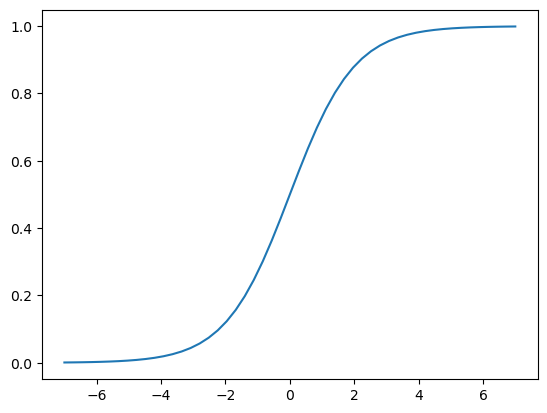

In [182]:
plt.plot(x, sigmoid(x))

In [183]:
from sklearn.linear_model import LogisticRegression
 
model = LogisticRegression()
model.fit(X_train, y_train)

D:\Anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [187]:
model.coef_[0]

array([ 4.74613189e-01, -1.74834822e-01, -4.07487023e-01, -2.97361562e-02,
       -7.79724995e-02,  6.26942018e-02, -8.90408337e-02, -8.13620237e-02,
       -3.43214810e-02, -7.33871747e-02, -3.35110640e-01,  3.16442818e-01,
       -8.90408337e-02,  3.68097061e-03, -2.58154682e-01,  1.41435345e-01,
        9.01068152e-03,  6.25400319e-02, -8.90408337e-02, -8.12078538e-02,
        2.65542674e-01, -8.90408337e-02, -2.84210496e-01, -2.31195036e-01,
        1.23486381e-01, -1.66047618e-01,  5.83389626e-02, -8.69911118e-02,
       -3.20490312e-02,  7.04599160e-02, -5.91284287e-02,  1.41435345e-01,
       -2.49144000e-01,  2.15427749e-01, -1.20311964e-01, -8.90408337e-02,
        1.01644142e-01, -7.08518550e-02, -8.90408337e-02,  5.21840331e-02,
        2.13343815e-01, -8.90408337e-02, -2.32011637e-01, -7.03695313e-02,
        3.81881557e-04])

In [188]:
model.intercept_
model.intercept_[0]

-0.1090634700754041

In [190]:
training_result = model.predict(X_train)

In [208]:
model.predict_proba(X_train)

array([[0.90458654, 0.09541346],
       [0.32065317, 0.67934683],
       [0.36628428, 0.63371572],
       ...,
       [0.46827884, 0.53172116],
       [0.95744532, 0.04255468],
       [0.30126582, 0.69873418]])

In [217]:
training_chrun_decision = (model.predict_proba(X_train)[:, 1] > 0.5)
((training_chrun_decision.astype(int)) == y_train).mean()

0.805207100591716

In [192]:
(training_result == y_train).mean()

0.805207100591716

In [202]:
y_pred = model.predict_proba(X_val)[:,1]
y_pred

array([0.0090045 , 0.20443038, 0.21211564, ..., 0.13644659, 0.7997995 ,
       0.83742463])

In [207]:
((y_pred > 0.5) == y_val).mean()

0.8034066713981547

In [218]:
churn_decision = y_pred >0.5
churn_decision

array([False, False, False, ..., False,  True,  True])

In [221]:
df_val[churn_decision].customerid.shape

(311,)

In [235]:
dv_v.get_feature_names_out()

array(['contract=Month-to-month', 'contract=One year',
       'contract=Two year', 'dependents=No', 'dependents=Yes',
       'deviceprotection=No', 'deviceprotection=No internet service',
       'deviceprotection=Yes', 'gender=Female', 'gender=Male',
       'internetservice=DSL', 'internetservice=Fiber optic',
       'internetservice=No', 'monthlycharges', 'multiplelines=No',
       'multiplelines=No phone service', 'multiplelines=Yes',
       'onlinebackup=No', 'onlinebackup=No internet service',
       'onlinebackup=Yes', 'onlinesecurity=No',
       'onlinesecurity=No internet service', 'onlinesecurity=Yes',
       'paperlessbilling=No', 'paperlessbilling=Yes', 'partner=No',
       'partner=Yes', 'paymentmethod=Bank transfer (automatic)',
       'paymentmethod=Credit card (automatic)',
       'paymentmethod=Electronic check', 'paymentmethod=Mailed check',
       'phoneservice=No', 'phoneservice=Yes', 'seniorcitizen',
       'streamingmovies=No', 'streamingmovies=No internet service',

In [238]:
model.coef_[0]

array([ 4.74613189e-01, -1.74834822e-01, -4.07487023e-01, -2.97361562e-02,
       -7.79724995e-02,  6.26942018e-02, -8.90408337e-02, -8.13620237e-02,
       -3.43214810e-02, -7.33871747e-02, -3.35110640e-01,  3.16442818e-01,
       -8.90408337e-02,  3.68097061e-03, -2.58154682e-01,  1.41435345e-01,
        9.01068152e-03,  6.25400319e-02, -8.90408337e-02, -8.12078538e-02,
        2.65542674e-01, -8.90408337e-02, -2.84210496e-01, -2.31195036e-01,
        1.23486381e-01, -1.66047618e-01,  5.83389626e-02, -8.69911118e-02,
       -3.20490312e-02,  7.04599160e-02, -5.91284287e-02,  1.41435345e-01,
       -2.49144000e-01,  2.15427749e-01, -1.20311964e-01, -8.90408337e-02,
        1.01644142e-01, -7.08518550e-02, -8.90408337e-02,  5.21840331e-02,
        2.13343815e-01, -8.90408337e-02, -2.32011637e-01, -7.03695313e-02,
        3.81881557e-04])

In [243]:
data = dict(zip(dv_v.get_feature_names_out(), model.coef_[0].round(3)))

In [245]:
sorted_dict = dict(sorted(data.items(), key=lambda item: item[1], reverse=True))

print(sorted_dict)

{'contract=Month-to-month': 0.475, 'internetservice=Fiber optic': 0.316, 'onlinesecurity=No': 0.266, 'seniorcitizen': 0.215, 'techsupport=No': 0.213, 'multiplelines=No phone service': 0.141, 'phoneservice=No': 0.141, 'paperlessbilling=Yes': 0.123, 'streamingmovies=Yes': 0.102, 'paymentmethod=Electronic check': 0.07, 'deviceprotection=No': 0.063, 'onlinebackup=No': 0.063, 'partner=Yes': 0.058, 'streamingtv=Yes': 0.052, 'multiplelines=Yes': 0.009, 'monthlycharges': 0.004, 'totalcharges': 0.0, 'dependents=No': -0.03, 'paymentmethod=Credit card (automatic)': -0.032, 'gender=Female': -0.034, 'paymentmethod=Mailed check': -0.059, 'tenure': -0.07, 'streamingtv=No': -0.071, 'gender=Male': -0.073, 'dependents=Yes': -0.078, 'deviceprotection=Yes': -0.081, 'onlinebackup=Yes': -0.081, 'paymentmethod=Bank transfer (automatic)': -0.087, 'deviceprotection=No internet service': -0.089, 'internetservice=No': -0.089, 'onlinebackup=No internet service': -0.089, 'onlinesecurity=No internet service': -0.08

In [254]:
top_5 = dict(list(sorted_dict.items())[:5])

In [255]:
top_5

{'contract=Month-to-month': 0.475,
 'internetservice=Fiber optic': 0.316,
 'onlinesecurity=No': 0.266,
 'seniorcitizen': 0.215,
 'techsupport=No': 0.213}

In [258]:
least_important_feature = dict(list(sorted_dict.items())[-1:])
least_important_feature

{'contract=Two year': -0.407}

# Using the model

In [275]:
full_data_dict = df_full_train[categorical + numerical].to_dict(orient='records')
test_dict = df_test[categorical + numerical].to_dict(orient='records')

In [276]:
dv_full = DictVectorizer(sparse=False)

dv_full.fit(full_data_dict)

X_full = dv_full.transform(full_data_dict)

In [277]:
dv_full.get_feature_names_out().shape

(45,)

In [278]:
X_test = dv_full.transform(test_dict)

In [279]:
full_model = LogisticRegression()

full_model.fit(X_full, y_full_train)

D:\Anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [280]:
full_training_prediction = model.predict(X_full)

In [283]:
(full_training_prediction == y_full_train).astype(int).mean()

0.8047568335108272

In [284]:
y_test_prediction = model.predict(X_test)

In [286]:
(y_test_prediction == y_test).astype(int).mean()

0.808374733853797